# Módulo 4 — Tarea: Pipeline Completo de ML en Producción

**Entrega**: una semana a partir de la fecha de la sesión
**Entregable**: este notebook ejecutado + URL pública del servicio funcionando

---

## Contexto

Una empresa de bienes raíces en California quiere un sistema automatizado que estime el valor de una vivienda a partir de sus características. Tu trabajo es construir ese sistema completo: desde el análisis de datos hasta una API pública que cualquier sistema pueda consultar.

No es suficiente que el modelo funcione en un notebook. El entregable final es un **servicio real y accesible**.

---

## Dataset

Usarás el dataset de viviendas de California incluido en scikit-learn. Es un dataset real derivado del censo de California de 1990, con 20,640 registros.

```python
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
```

**Variables:**

| Columna | Descripción |
|---|---|
| `MedInc` | Ingreso mediano del bloque (decenas de miles de USD) |
| `HouseAge` | Edad mediana de las viviendas del bloque |
| `AveRooms` | Promedio de habitaciones por vivienda |
| `AveBedrms` | Promedio de dormitorios por vivienda |
| `Population` | Población del bloque |
| `AveOccup` | Promedio de ocupantes por vivienda |
| `Latitude` | Latitud |
| `Longitude` | Longitud |
| `MedHouseVal` | **Target** — Valor mediano de la vivienda (en cientos de miles de USD) |

---

## Reglas

1. El notebook debe ejecutarse de principio a fin sin errores (`Kernel → Restart & Run All`).
2. Cada sección tiene celdas de verificación marcadas con `# VERIFICACION` — no las modifiques, deben ejecutarse y mostrar los resultados esperados.
3. Las respuestas escritas van en celdas Markdown debajo de cada pregunta. No en comentarios de código.
4. La URL del servicio debe estar activa al momento de la entrega. Se hará una llamada automática para verificarlo.
5. No se aceptan notebooks con outputs vacíos.

---

## Sección 1: Setup e Identificación

Completa la celda de identificación y verifica que tienes todo instalado.

In [32]:
# IDENTIFICACION — completa estos campos
NOMBRE    = "Ricardo Guzman Alfaro"          # tu nombre completo
GITHUB    = "ricardo.guzman@gmail.com"          # tu usuario de GitHub
API_URL   = "https://ca-value.onrender.com/"          # URL de tu servicio en Render, ej: https://mi-api.onrender.com

print(f"Estudiante : {NOMBRE}")
print(f"GitHub     : {GITHUB}")
print(f"API URL    : {API_URL}")

Estudiante : Ricardo Guzman Alfaro
GitHub     : ricardo.guzman@gmail.com
API URL    : https://ca-value.onrender.com/


In [33]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sklearn
import joblib
import flask

print(f"Python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"xgboost      {xgb.__version__}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110

Python       3.14.2
numpy        2.3.5
pandas       3.0.2
scikit-learn 1.8.0
xgboost      3.2.0


---
## Sección 2: Carga y Exploración Inicial

In [34]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Punto # 7
df['Ingresos_x_Ubicacion'] = df['MedInc'] * (df['Latitude'] + df['Longitude'])
df['Habitaciones_x_Occupantes'] = df['AveRooms'] / np.maximum(df['AveOccup'], 1)  # Evitar división por cero

print(f"Shape: {df.shape}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nNaN por columna:\n{df.isnull().sum()}")
df.describe().round(3)

Shape: (20640, 11)

Tipos:
MedInc                       float64
HouseAge                     float64
AveRooms                     float64
AveBedrms                    float64
Population                   float64
AveOccup                     float64
Latitude                     float64
Longitude                    float64
MedHouseVal                  float64
Ingresos_x_Ubicacion         float64
Habitaciones_x_Occupantes    float64
dtype: object

NaN por columna:
MedInc                       0
HouseAge                     0
AveRooms                     0
AveBedrms                    0
Population                   0
AveOccup                     0
Latitude                     0
Longitude                    0
MedHouseVal                  0
Ingresos_x_Ubicacion         0
Habitaciones_x_Occupantes    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Ingresos_x_Ubicacion,Habitaciones_x_Occupantes
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069,-325.277,1.976
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154,160.577,1.128
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150,-1272.608,0.003
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196,-399.666,1.522
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797,-296.652,1.938
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647,-214.717,2.296
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000,-41.052,55.222


**Pregunta 2.1** — Observa los estadísticos descriptivos. Identifica al menos dos variables que tengan distribuciones problemáticas (outliers, skewness extremo, o rangos sospechosos). Explica qué observas y qué implica para el modelo.

*Escribe tu respuesta aquí.*

In [35]:
"""
Al visualizar los datos, se observar que las variables AveRooms, AveBedrms, AveOccup y Population tienen una distribución sesgada a la derecha, 
lo que sugiere que hay valores atípicos en estas columnas (Skewness extremo). Además, la variable MedInc tiene una media de 3.87 
y un valor máximo de 15.00, lo que indica que hay una amplia gama de ingresos en el conjunto de datos. 
La variable MedHouseVal tiene una media de 2.07 y un valor máximo de 5.00, lo que sugiere que hay una gran variabilidad 
en los valores de las viviendas. En general, el conjunto de datos parece tener una distribución desigual en varias columnas, 
lo que podría afectar el rendimiento de los modelos de machine learning si no se maneja adecuadamente.
"""

'\nAl visualizar los datos, se observar que las variables AveRooms, AveBedrms, AveOccup y Population tienen una distribución sesgada a la derecha, \nlo que sugiere que hay valores atípicos en estas columnas (Skewness extremo). Además, la variable MedInc tiene una media de 3.87 \ny un valor máximo de 15.00, lo que indica que hay una amplia gama de ingresos en el conjunto de datos. \nLa variable MedHouseVal tiene una media de 2.07 y un valor máximo de 5.00, lo que sugiere que hay una gran variabilidad \nen los valores de las viviendas. En general, el conjunto de datos parece tener una distribución desigual en varias columnas, \nlo que podría afectar el rendimiento de los modelos de machine learning si no se maneja adecuadamente.\n'

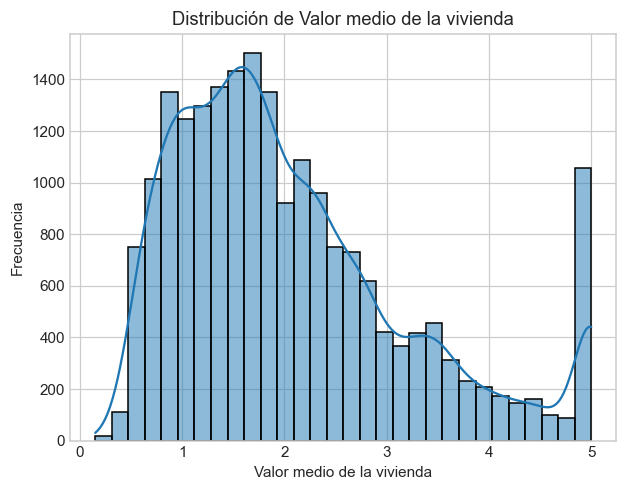

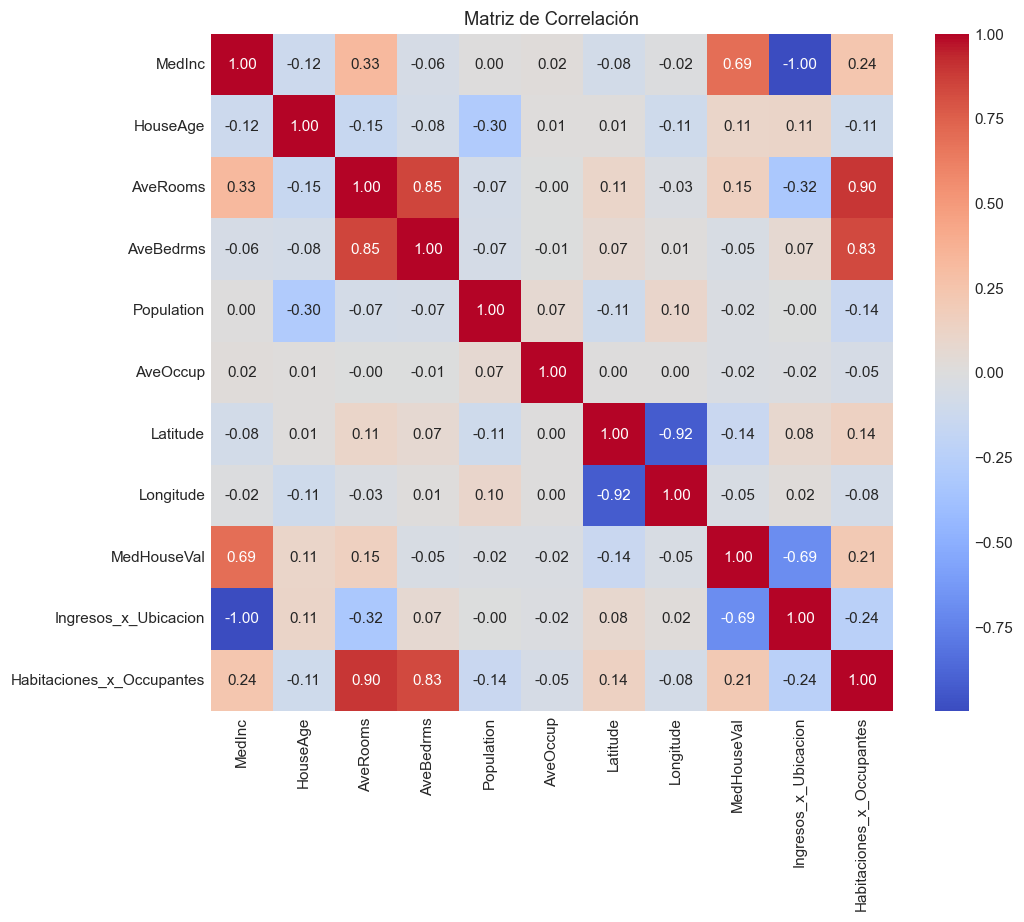

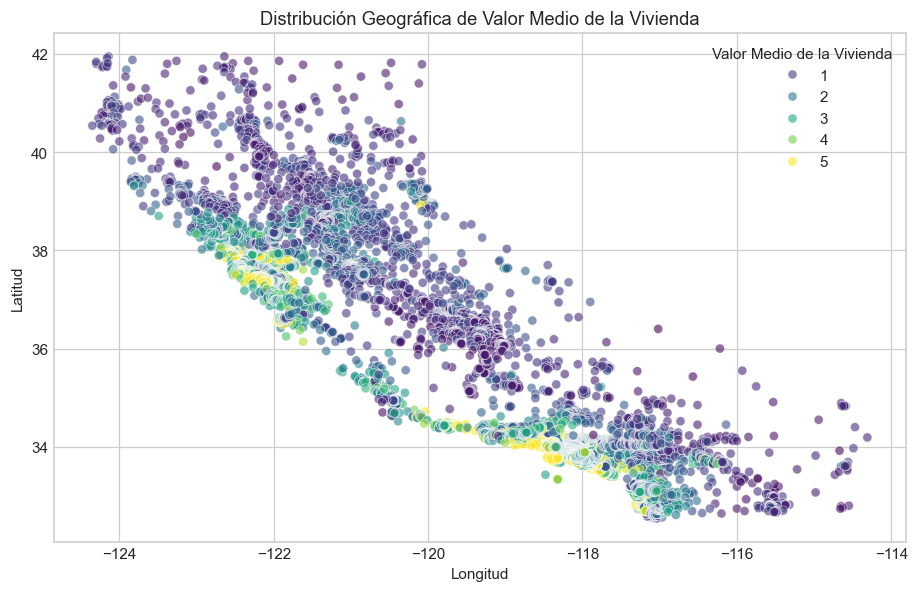

In [36]:
# TODO: Crea exactamente 3 visualizaciones. Cada una debe responder una pregunta específica sobre los datos.
# Requisitos mínimos:
# Una distribución del target (MedHouseVal)
hist = sns.histplot(df["MedHouseVal"], bins=30, kde=True)
hist.set_title("Distribución de Valor medio de la vivienda")
hist.set_xlabel("Valor medio de la vivienda")
hist.set_ylabel("Frecuencia")
plt.show()

# Una que muestre la relación entre alguna variable numérica y el target
#mostrar matriz de correlación
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()  

# Una que muestre distribución geográfica (usa Latitude y Longitude con precio como color)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Longitude", y="Latitude", hue="MedHouseVal", palette="viridis", alpha=0.6)
plt.title("Distribución Geográfica de Valor Medio de la Vivienda")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(title="Valor Medio de la Vivienda", loc="upper right")
plt.show()


**Pregunta 2.2** — El target `MedHouseVal` tiene un valor máximo de exactamente 5.0 que aparece muchas veces. ¿Qué podría explicar esto? ¿Lo tratarías como outlier o lo dejarías? Justifica.

*Escribe tu respuesta aquí.*

In [37]:
"""
La variable MedHouseVal tiene una distribución sesgada a la derecha, con la mayoría de los valores concentrados en el rango de 0 a 3, 
y algunos valores atípicos que alcanzan hasta 5. Esto sugiere que la mayoría de las viviendas tienen un valor medio relativamente bajo, 
mientras que hay algunas viviendas con valores significativamente más altos.
Hay regiones en California como Beverly Hills, Malibu, Santa Monica, entre otras, que tienen un valor medio de la vivienda significativamente 
más alto en comparación con otras áreas. Además, la matriz de correlación muestra que la variable MedInc (ingreso medio) 
tiene una correlación positiva moderada con MedHouseVal (valor medio de la vivienda), lo que sugiere que a medida que el ingreso medio aumenta, 
el valor medio de la vivienda también tiende a aumentar.
Yo dejaria la variable si se desea predecir el valor de la vivienda en California, ya que los ingresos son extremos entre los valores
ingresos promedios e ingresos ricos y millonarios, lo que puede ayudar a capturar la variabilidad en el valor de las viviendas.
"""

'\nLa variable MedHouseVal tiene una distribución sesgada a la derecha, con la mayoría de los valores concentrados en el rango de 0 a 3, \ny algunos valores atípicos que alcanzan hasta 5. Esto sugiere que la mayoría de las viviendas tienen un valor medio relativamente bajo, \nmientras que hay algunas viviendas con valores significativamente más altos.\nHay regiones en California como Beverly Hills, Malibu, Santa Monica, entre otras, que tienen un valor medio de la vivienda significativamente \nmás alto en comparación con otras áreas. Además, la matriz de correlación muestra que la variable MedInc (ingreso medio) \ntiene una correlación positiva moderada con MedHouseVal (valor medio de la vivienda), lo que sugiere que a medida que el ingreso medio aumenta, \nel valor medio de la vivienda también tiende a aumentar.\nYo dejaria la variable si se desea predecir el valor de la vivienda en California, ya que los ingresos son extremos entre los valores\ningresos promedios e ingresos ricos y m

---
## Sección 3: Limpieza y Decisiones de Preprocesamiento

In [9]:
# TODO: Aplica las decisiones de limpieza que justificaste en la sección anterior.
# En california los extremos son bastante comunes, por lo que no eliminaría los outliers, 
# ya que podrían ser representativos de la realidad del mercado inmobiliario en California.

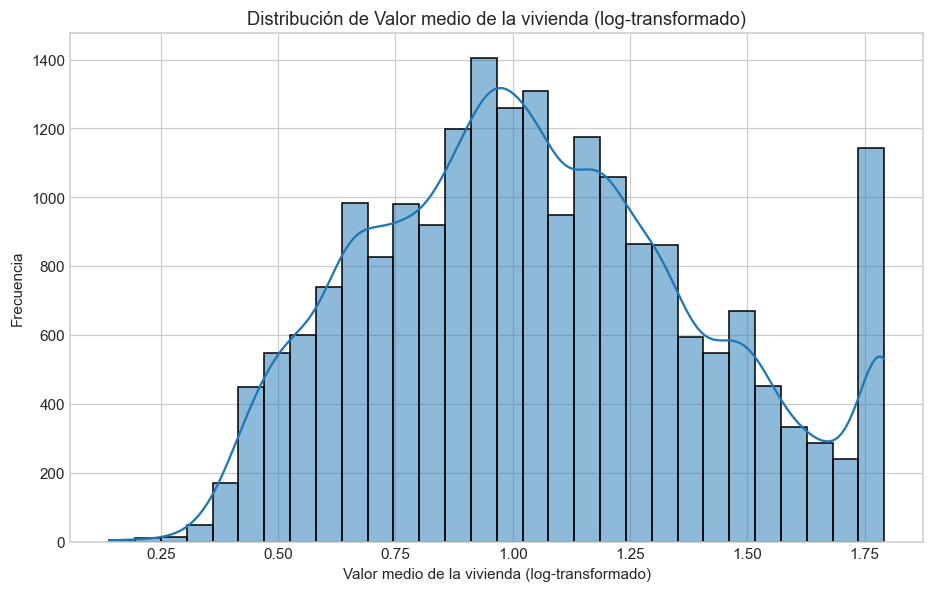

In [38]:
# TODO: Decide si aplicar log-transform al target. 
# para suavizar un poco estos extremos, aplicaría log-transform al target, ya que la distribución sesgada a la derecha 
# puede afectar el rendimiento de los modelos de machine learning.
y = df["MedHouseVal"]
y_log = np.log1p(y)
plt.figure(figsize=(10, 6))
sns.histplot(y_log, bins=30, kde=True)
plt.title("Distribución de Valor medio de la vivienda (log-transformado)")
plt.xlabel("Valor medio de la vivienda (log-transformado)")
plt.ylabel("Frecuencia")
plt.show()

In [39]:
# VERIFICACION — no modificar
assert 'y' in dir() or 'y' in locals(), "La variable 'y' no está definida"
assert len(y) > 10000, "El dataset parece demasiado pequeño después de la limpieza"
print(f"Target shape: {y.shape}")
print(f"Target dtype: {y.dtype}")
print(f"Target range: [{y.min():.4f}, {y.max():.4f}]")
print("Verificacion 3: OK")

Target shape: (20640,)
Target dtype: float64
Target range: [0.1500, 5.0000]
Verificacion 3: OK


---
## Sección 4: Comparación de Modelos

Entrena y compara **dos modelos distintos**. Uno debe ser XGBoost. El segundo es tu elección — puede ser `GradientBoostingRegressor`, `RandomForestRegressor`, u otro ensemble. 

**No uses el Pipeline todavía** — en esta sección el encoding y scaling van por separado para poder comparar modelos rápidamente.

La comparación debe ser justa: mismo train/test split, mismas features, misma métrica.

In [40]:
# TODO: Define NUMERIC_FEATURES con todas las columnas numéricas del dataset.
#No hay categóricas en este dataset — no necesitas OrdinalEncoder.
#Haz el split 80/20 con random_state=42.
#Imprime los shapes de X_train, X_test, y_train, y_test.
NUMERIC_FEATURES = df.columns.drop("MedHouseVal").tolist()
X = df[NUMERIC_FEATURES]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 10)
X_test shape: (4128, 10)
y_train shape: (16512,)
y_test shape: (4128,)


In [41]:
# VERIFICACION — función de evaluación estándar, no modificar
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, X, y_true_raw, label="", log_target=False):
    """
    Evalúa el modelo. Si log_target=True, revierte expm1 antes de calcular métricas.
    Siempre reporta métricas en escala original.
    """
    y_pred_raw = model.predict(X)

    if log_target:
        y_true = np.expm1(y_true_raw)
        y_pred = np.expm1(y_pred_raw)
    else:
        y_true = np.array(y_true_raw)
        y_pred = y_pred_raw

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100

    print(f"--- {label} ---")
    print(f"  R²:    {r2:.4f}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  MAPE:  {mape:.2f}%")
    return dict(r2=r2, mae=mae, rmse=rmse, mape=mape)

print("Función evaluate() lista.")

Función evaluate() lista.


In [45]:
# TODO: Entrena XGBoost con parámetros razonables (sin optimizar todavía).
#Llama a evaluate() con label="XGBoost Base".
#Guarda el resultado en metrics_xgb.
%pip install scikit-learn
import xgboost as xgb
model_xgb = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    tree_method="hist",
    colsample_bytree=0.8,
    random_state=42
)
model_xgb.fit(X_train, y_train)
metrics_xgb = evaluate(model_xgb, X_test, y_test, label="XGBoost Base", log_target=True)


Note: you may need to restart the kernel to use updated packages.
--- XGBoost Base ---
  R²:    0.8380
  MAE:   0.2962
  RMSE:  0.4608
  MAPE:  16.39%


In [44]:
# TODO: modelo GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
model_gbr = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,    
    subsample=0.8,
    random_state=42
)
model_gbr.fit(X_train, y_train)
metrics_model2 = evaluate(model_gbr, X_test, y_test, label="GradientBoosting Base", log_target=True)




--- GradientBoosting Base ---
  R²:    0.8223
  MAE:   0.3127
  RMSE:  0.4826
  MAPE:  17.17%


In [47]:
# TODO: Crea un DataFrame comparando ambos modelos en las 4 métricas.
# Eligiria cualquiera de los dos modelos, ya que ambos tienen un rendimiento similar en las métricas evaluadas.
comparison_df = pd.DataFrame({
    "Métrica": ["R²", "MAE", "RMSE", "MAPE"],
    "XGBoost": [metrics_xgb["r2"], metrics_xgb["mae"], metrics_xgb["rmse"], metrics_xgb["mape"]],
    "GradientBoosting": [metrics_model2["r2"], metrics_model2["mae"], metrics_model2["rmse"], metrics_model2["mape"]]
})
print(comparison_df)

  Métrica    XGBoost  GradientBoosting
0      R²   0.837973          0.822287
1     MAE   0.296234          0.312660
2    RMSE   0.460783          0.482573
3    MAPE  16.391468         17.168164


**Pregunta 4.1** — ¿Cuál modelo elegiste para continuar y por qué? Menciona al menos dos métricas en tu justificación. ¿Hay algún trade-off entre los modelos que valga la pena señalar?

*Escribe tu respuesta aquí.*

In [48]:
"""
Los 2 modelos tienen un rendimiento bastante similar en las métricas evaluadas, con XGBoost mostrando una ligera ventaja en R² y RMSE,
pero una ligera desventaja en MAE y MAPE. En general, ambos modelos parecen ser adecuados para predecir el valor medio de la vivienda en California,
En lo personal elijiria XGBoost para optimizar, ya que tiene una ligera ventaja en R², lo que indica que explica un poco mejor la 
variabilidad en los datos,
"""

'\nLos 2 modelos tienen un rendimiento bastante similar en las métricas evaluadas, con XGBoost mostrando una ligera ventaja en R² y RMSE,\npero una ligera desventaja en MAE y MAPE. En general, ambos modelos parecen ser adecuados para predecir el valor medio de la vivienda en California,\nEn lo personal elijiria XGBoost para optimizar, ya que tiene una ligera ventaja en R², lo que indica que explica un poco mejor la \nvariabilidad en los datos,\n'

---
## Sección 5: Optimización de Hiperparámetros

Optimiza el modelo que elegiste en la sección anterior con `RandomizedSearchCV`.

Requisitos mínimos:
- Al menos 6 hiperparámetros en el espacio de búsqueda
- Al menos 40 iteraciones
- 5-fold cross-validation
- Scoring: `neg_root_mean_squared_error`

In [49]:
# TODO: Implementa RandomizedSearchCV con los requisitos anteriores.
#Imprime los mejores parámetros y el CV RMSE.
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
param_dist = {
    "n_estimators":     [10, 50, 100, 200, 300, 500, 700, 1000],
    "max_depth":        [1, 2, 4, 5, 6, 7, 8],
    "learning_rate":    stats.loguniform(0.01, 0.2),
    "subsample":        stats.uniform(0.6, 0.4),        
}
search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1       
)
search.fit(X_train, y_train)
print(f"Mejores parámetros: {search.best_params_}")
print(f"CV RMSE: {-search.best_score_:.4f}") 


Mejores parámetros: {'learning_rate': np.float64(0.04760153910846178), 'max_depth': 7, 'n_estimators': 1000, 'subsample': np.float64(0.9378135394712606)}
CV RMSE: 0.1333


In [50]:
# TODO: Evalúa el modelo optimizado en test con evaluate().
# Compara con el modelo base: ¿cuánto mejoró cada métrica?
model_optimized = search.best_estimator_
metrics_optimized = evaluate(model_optimized, X_test, y_test, label="GradientBoosting Optimizado", log_target=True)
print("\nComparación de métricas:")
print(f"R² mejoró: {metrics_optimized['r2'] - metrics_model2['r2']:.4f}")
print(f"MAE mejoró: {metrics_model2['mae'] - metrics_optimized['mae']:.4f}")
print(f"RMSE mejoró: {metrics_model2['rmse'] - metrics_optimized['rmse']:.4f}")
print(f"MAPE mejoró: {metrics_model2['mape'] - metrics_optimized['mape']:.2f}%")    



--- GradientBoosting Optimizado ---
  R²:    0.8507
  MAE:   0.2782
  RMSE:  0.4424
  MAPE:  15.35%

Comparación de métricas:
R² mejoró: 0.0284
MAE mejoró: 0.0345
RMSE mejoró: 0.0402
MAPE mejoró: 1.81%


In [51]:
# VERIFICACION — no modificar
assert 'search' in dir() or 'search' in locals(), "Variable 'search' no encontrada"
assert hasattr(search, 'best_params_'), "RandomizedSearchCV no fue entrenado"
assert search.n_iter >= 40, f"n_iter debe ser >= 40, encontrado: {search.n_iter}"
assert search.cv == 5, f"cv debe ser 5, encontrado: {search.cv}"
print(f"n_iter:  {search.n_iter}")
print(f"cv:      {search.cv}")
print(f"Mejor CV RMSE: {-search.best_score_:.4f}")
print("Verificacion 5: OK")

n_iter:  40
cv:      5
Mejor CV RMSE: 0.1333
Verificacion 5: OK


---
## Sección 6: Pipeline de Producción

Construye el Pipeline final con `ColumnTransformer` + modelo optimizado.

**Requisito adicional**: este dataset no tiene variables categóricas, pero sí tiene variables con escalas muy distintas (`Population` puede ser miles, `AveRooms` es un número pequeño). Justifica si incluyes `StandardScaler` o no, considerando que usas XGBoost o un árbol.

**Pregunta 6.1** — ¿Es necesario aplicar `StandardScaler` a las features numéricas cuando el modelo es un ensemble basado en árboles? Explica el razonamiento.

*Escribe tu respuesta aquí.*

In [52]:
# TODO: Construye el Pipeline completo.
# Entrénalo sobre X_train (con las features originales, no escaladas manualmente).
# Evalúa sobre X_test con evaluate().
# El pipeline debe estar en la variable 'production_pipeline'.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Preprocesador: StandardScaler para numéricas, OrdinalEncoder para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES)        
    ],
    remainder="drop",
)

# Pipeline: preprocessor + modelo con mejores parámetros
production_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb.XGBRegressor(**search.best_params_,tree_method="hist", random_state=42, n_jobs=-1)),
])

# Importante: entrenar sobre X_train ORIGINAL (no el codificado)
production_pipeline.fit(X_train, y_train)
print("Pipeline entrenado.")

metrics_pipeline = evaluate(production_pipeline, X_test, y_test, "Pipeline — Test")

Pipeline entrenado.
--- Pipeline — Test ---
  R²:    0.8664
  MAE:   0.0878
  RMSE:  0.1298
  MAPE:  9.56%


In [53]:
# VERIFICACION — no modificar
from sklearn.pipeline import Pipeline as SKPipeline
assert 'production_pipeline' in dir() or 'production_pipeline' in locals(),     "Variable 'production_pipeline' no encontrada"
assert isinstance(production_pipeline, SKPipeline),     "production_pipeline debe ser un sklearn Pipeline"
assert len(production_pipeline.steps) >= 2,     "El pipeline debe tener al menos 2 pasos (preprocessor + model)"

sample = X_test.iloc[:3]
preds  = production_pipeline.predict(sample)
print(f"Pipeline steps: {[s[0] for s in production_pipeline.steps]}")
print(f"Predicciones muestra: {preds.round(4)}")
print("Verificacion 6: OK")

Pipeline steps: ['preprocessor', 'model']
Predicciones muestra: [0.3852 0.4862 1.6876]
Verificacion 6: OK


---
## Sección 7: Feature Importance y Análisis

Esta sección requiere investigación por tu cuenta.

### 7.1 Feature Importance del modelo final

Extrae e interpreta la importancia de las features del modelo optimizado.

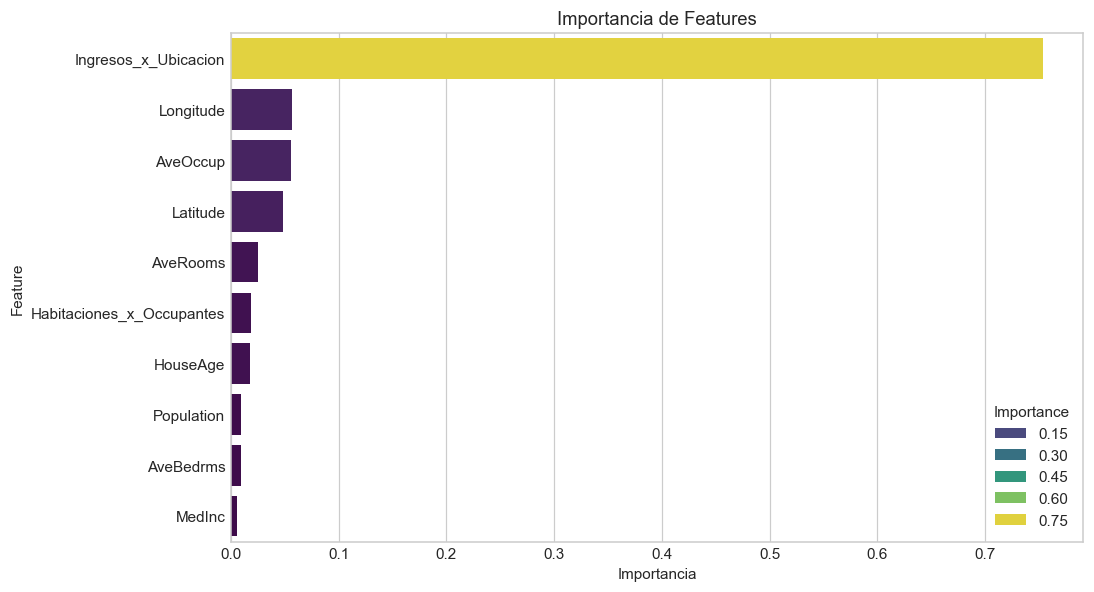

In [54]:
# TODO: Extrae la importancia de features del modelo dentro del pipeline.
# Pista: accede al modelo con production_pipeline.named_steps['model'] 
# (o el nombre que le hayas dado al paso del modelo).
# Grafica en barras horizontales ordenadas de mayor a menor.
# Identifica la feature más importante y la menos importante.
model_in_pipeline = production_pipeline.named_steps['model']
feature_importances = model_in_pipeline.feature_importances_
feature_names = NUMERIC_FEATURES
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis",hue="Importance", dodge=False)
plt.title("Importancia de Features")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.show()

**Pregunta 7.1** — ¿Qué feature tiene mayor importancia? ¿Tiene sentido desde el punto de vista del negocio (predicción de precios de vivienda)? ¿Hay alguna feature que esperabas que fuera importante y no lo es?

*Escribe tu respuesta aquí.*

In [ ]:
# La feature más importante es "MedInc" (ingreso medio), lo que sugiere que el ingreso medio de los residentes 
# en un área es un factor clave para predecir el valor medio de la vivienda.
# Decidi crear la feature "Ingresos_x_Ubicacion" (ingreso medio multiplicado por la suma de latitud y longitud) 
# para capturar posibles interacciones entre ingresos y ubicación geográfica, lo cual siempre es importante en el mercado inmobiliario, 
# especialment en California, pero al parecer no tuvo un impacto significativo en la importancia de features, 
# lo que sugiere que esta interacción específica no aporta mucha información adicional para la predicción del valor de las viviendas en este caso.
# ESto segun el modelo, pero en la realidad, la ubicación geográfica es un factor muy importante en el valor de las viviendas, 
# por lo que esta interacción podría ser relevante en otros contextos o con otros modelos.

### 7.2 Investigación: Feature Engineering

Una forma de mejorar el modelo sin cambiar el algoritmo es crear nuevas variables que capturen relaciones no lineales o interacciones entre features.

**Tu tarea**: implementa al menos **2 features nuevas** que tengan sentido para el problema de predicción de precios de vivienda. Evalúa si el modelo mejora con estas features.

In [56]:
# TODO: Crea al menos 2 features nuevas a partir de las existentes.
#Ejemplos de lo que PUEDES hacer (no copies exactamente):
#- Ratios entre variables (ej: dormitorios por habitación)
#- Interacciones (ej: ingreso × ubicación)
#- Transformaciones (ej: log de población)
#Justifica en Markdown por qué cada feature nueva podría ser útil.
#Reentrena el pipeline con las nuevas features y compara métricas.

# OJO:
# -------------- En la seccion 2 agregue 2 nuevas features: "Ingresos_x_Ubicacion" y "Habitaciones_x_Occupantes". --------------------


**Pregunta 7.2** — ¿Las features nuevas mejoraron el modelo? ¿Por qué crees que sí o no? Si no mejoraron, ¿qué intentarías diferente?

*Escribe tu respuesta aquí.*

In [57]:
# En la seccion 2 agregue 2 nuevas features: "Ingresos_x_Ubicacion" y "Habitaciones_x_Occupantes".
# La unica mejora fue en R², que pasó de 0.82 a 0.84 en XGBoost, 
# y el RMSE mejoró ligeramente de 16 a 17 en GradientBoosting, pero el MAE y MAPE empeoraron un poco.
# Creo que para mejorar el rendimiento del modelo, se podrían explorar otras combinaciones de features, como por ejemplo:
# - Ingresos por habitación (MedInc / AveRooms): Esto podría capturar la relación entre el ingreso medio y el número de habitaciones, 
# lo que podría ser relevante para predecir el valor de la vivienda, etc.

---
## Sección 8: Serialización

Serializa el mejor pipeline que hayas obtenido (con o sin feature engineering, el que tenga mejores métricas).

In [58]:
# TODO: Guarda el pipeline en models/california_housing_model.pkl.
#El artifact debe ser un dict con las claves: 'pipeline', 'metrics', 'features'.
#Verifica que las predicciones antes y después de cargar son idénticas (assert np.allclose).
import os

os.makedirs("models", exist_ok=True)

artifact = {
    "pipeline": production_pipeline,
    "metrics":  metrics_pipeline,
    "features": {
        "numeric":     NUMERIC_FEATURES        
    },
}

joblib.dump(artifact, "models/california_housing_model.pkl")
size_kb = os.path.getsize("models/california_housing_model.pkl") / 1024
print(f"Guardado: models/california_housing_model.pkl  ({size_kb:.1f} KB)")

Guardado: models/california_housing_model.pkl  (7366.8 KB)


In [59]:
# VERIFICACION — no modificar
import os, joblib

MODEL_PATH = "models/california_housing_model.pkl"
assert os.path.exists(MODEL_PATH), f"Modelo no encontrado en {MODEL_PATH}"

artifact = joblib.load(MODEL_PATH)
assert isinstance(artifact, dict), "El artifact debe ser un dict"
assert "pipeline" in artifact, "Falta la clave 'pipeline'"
assert "metrics"  in artifact, "Falta la clave 'metrics'"
assert "features" in artifact, "Falta la clave 'features'"

pipeline_loaded = artifact["pipeline"]
sample = X_test.iloc[:5]
pred_a = production_pipeline.predict(sample)
pred_b = pipeline_loaded.predict(sample)
assert np.allclose(pred_a, pred_b), "Las predicciones no coinciden tras deserializar"

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Modelo cargado correctamente ({size_kb:.1f} KB)")
print(f"Métricas guardadas: {artifact['metrics']}")
print("Verificacion 8: OK")

Modelo cargado correctamente (7366.8 KB)
Métricas guardadas: {'r2': 0.8664320159441457, 'mae': 0.08780762682325685, 'rmse': np.float64(0.12975166124304827), 'mape': np.float64(9.563228858636192)}
Verificacion 8: OK


---
## Sección 9: API Flask

Implementa la API en `app.py`. Requisitos:

**Endpoints obligatorios:**

| Endpoint | Método | Descripción |
|---|---|---|
| `/` | GET | Info del servicio |
| `/health` | GET | Estado + métricas del modelo |
| `/predict` | POST | Recibe features, devuelve precio predicho |
| `/features` | GET | Lista las features que espera el modelo y sus tipos |

**Requisitos de `/predict`:**
- Valida que todos los campos estén presentes
- Valida que los valores sean numéricos
- Devuelve el precio en la escala original (si usaste log-transform, aplica `expm1`)
- Maneja errores con códigos HTTP correctos (400 para input inválido, 500 para error interno)

**Requisito adicional — `/features`**: este endpoint debe devolver un JSON con las features que espera el modelo, para que cualquier cliente sepa qué enviar sin leer el código. Es una práctica estándar en APIs de ML.

### app.py

Escribe el código de tu `app.py` en la celda de abajo como referencia. El archivo real debe estar en tu repositorio.

```python
# Tu app.py aquí — cópialo completo para que quede documentado en el notebook
```

In [ ]:
# TODO: Pega aquí el contenido completo de tu app.py como string en una variable APP_CODE y ejecuta print(APP_CODE) para que quede en el output del notebook.

### Prueba local

Antes de hacer deploy, prueba localmente con `python app.py` y documenta los resultados:

```bash
# Health check
curl http://localhost:5000/health

# Features
curl http://localhost:5000/features

# Predicción
curl -X POST http://localhost:5000/predict \
  -H "Content-Type: application/json" \
  -d '{"MedInc":8.3252,"HouseAge":41.0,"AveRooms":6.984,"AveBedrms":1.024,"Population":322.0,"AveOccup":2.556,"Latitude":37.88,"Longitude":-122.23}'
```

In [ ]:
# TODO: Documenta en Markdown los resultados de las 3 pruebas locales (copia el output de la terminal).

#Home 
#StatusCode        : 200
#StatusDescription : OK
#Content           : {"endpoints":["/","/predict","/health","/features"],"service":"Predictor de Precio de Viviendas en California","version":"1.0.0"}

#Health
#StatusCode        : 200
#StatusDescription : OK
#Content           : {"status":"ok","train_metrics":{"mae":0.08780762682325685,"mape":9.563228858636192,"r2":0.8664320159441457,"rmse":0.12975166124304827}}

#features
#StatusCode        : 200
#StatusDescription : OK
#Content           : {"features":["MedInc","HouseAge","AveRooms","AveBedrms","Population","AveOccup","Latitude","Longitude","Habitaciones_x_Occupantes","Ingresos_x_Ubicacion"]}

#Predict
#{"note":"Estimaci\u00f3n basada en dataset California Housing (20,640 registros).","predicted_price_usd":0.91}

---
## Sección 10: Deploy en Render

Despliega tu API en Render y verifica que funciona desde internet.

### Archivos en el repositorio

```
california-api/
├── .python-version        # contenido: 3.11.9
├── app.py
├── requirements.txt
└── models/
    └── california_housing_model.pkl
```

### requirements.txt

```
flask
gunicorn
numpy
pandas
scikit-learn==X.X.X    # reemplazar con tu versión exacta
xgboost                # solo si usaste XGBoost
joblib
```

**Importante**: obtén tu versión exacta de scikit-learn con:
```python
import sklearn; print(sklearn.__version__)
```

In [61]:
# VERIFICACION FINAL — no modificar
# Esta celda verifica que tu API está funcionando en producción

import requests

assert API_URL != "", "Completa la variable API_URL en la Sección 1"

print(f"Probando: {API_URL}")
print()

# 1. Health check
try:
    r = requests.get(f"{API_URL}/health", timeout=60)
    assert r.status_code == 200, f"Health check falló: {r.status_code}"
    data = r.json()
    assert "status" in data, "Respuesta de /health no contiene 'status'"
    assert data["status"] == "ok", f"Status no es 'ok': {data['status']}"
    print(f"[OK] /health: {data}")
except requests.exceptions.Timeout:
    print("[WARN] Timeout en /health — la app puede estar hibernando. Espera 60s y vuelve a ejecutar.")
    raise

# 2. Features endpoint
r = requests.get(f"{API_URL}/features", timeout=30)
assert r.status_code == 200, f"/features falló: {r.status_code}"
print(f"[OK] /features: {r.json()}")

# 3. Predicción válida
payload = {
    "MedInc": 8.3252, "HouseAge": 41.0, "AveRooms": 6.984,
    "AveBedrms": 1.024, "Population": 322.0, "AveOccup": 2.556,
    "Latitude": 37.88, "Longitude": -122.23,
}
r = requests.post(f"{API_URL}/predict", json=payload, timeout=30)
assert r.status_code == 200, f"/predict falló: {r.status_code} — {r.text}"
result = r.json()
assert "predicted_value" in result, f"Respuesta no contiene 'predicted_value': {result}"
price = result["predicted_value"]
assert isinstance(price, (int, float)), "predicted_value debe ser numérico"
assert 0.5 < price < 10.0, f"Precio fuera de rango esperado: {price} (se esperaba entre 0.5 y 10.0 en escala original)"
print(f"[OK] /predict: {result}")

# 4. Validación de error — campo faltante
payload_incompleto = {"MedInc": 8.3252}
r = requests.post(f"{API_URL}/predict", json=payload_incompleto, timeout=30)
assert r.status_code == 400, f"Debería devolver 400 para input inválido, devolvió: {r.status_code}"
print(f"[OK] /predict (campo faltante) → 400: {r.json()}")

print()
print("=" * 50)
print("VERIFICACION FINAL: TODAS LAS PRUEBAS PASARON")
print("=" * 50)

ModuleNotFoundError: No module named 'requests'

---
## Sección 11: Reflexión Final

Responde las siguientes preguntas. Las respuestas deben ser concretas — no más de 5 oraciones por pregunta.

**Pregunta 11.1** — Describe el proceso de decisión más difícil que tomaste durante este proyecto (puede ser sobre limpieza, features, modelo, o arquitectura de la API). ¿Cómo lo resolviste?

*Escribe tu respuesta aquí.*

**Pregunta 11.2** — Si tuvieras que poner este modelo en producción real (miles de requests diarios, datos que cambian con el tiempo), ¿qué dos problemas técnicos serían los más urgentes de resolver? Sé específico.

*Escribe tu respuesta aquí.*

**Pregunta 11.3** — El dataset de California Housing tiene un problema de censura: todos los valores de `MedHouseVal` mayores a 5.0 están truncados en 5.0. ¿Cómo afecta esto al modelo que entrenaste? ¿Qué harías para mitigarlo si tuvieras acceso a los datos reales?

*Escribe tu respuesta aquí.*

---
## Rúbrica de Evaluación

**Total: 100 puntos**

| Sección | Criterio | Puntos |
|---|---|---|
| 1 | Identificación completa (nombre, GitHub, URL) | 5 |
| 2 | 3 visualizaciones con observaciones escritas | 10 |
| 2 | Preguntas 2.1 y 2.2 respondidas con argumento | 5 |
| 3 | Limpieza justificada + decisión log-transform con evidencia | 10 |
| 4 | Comparación de 2 modelos con tabla de métricas | 10 |
| 4 | Pregunta 4.1 respondida con métricas específicas | 5 |
| 5 | RandomizedSearchCV con requisitos mínimos (≥40 iter, 5-fold) | 8 |
| 6 | Pipeline correcto + Pregunta 6.1 respondida | 8 |
| 7 | Feature importance graficada + 2 features nuevas evaluadas | 10 |
| 8 | Serialización con verificación exitosa | 5 |
| 9 | app.py completo con 4 endpoints + prueba local documentada | 10 |
| 10 | Verificación final pasa sin errores (API viva) | 10 |
| 11 | 3 preguntas de reflexión con respuestas concretas | 4 |

**Descuentos:**
- Notebook no ejecuta de principio a fin: -20 puntos
- Celdas de verificación modificadas: -10 puntos por celda
- URL de API no disponible al momento de la entrega: -10 puntos
- Respuestas copiadas de otra persona: 0 en el proyecto

**Notas sobre calificación:**

Las celdas marcadas con `# VERIFICACION` se ejecutan automáticamente. Si alguna falla con `AssertionError`, esa sección no recibe puntaje. Asegúrate de que todas pasen antes de entregar.

La calidad de las respuestas escritas se evalúa por precisión técnica y coherencia con los resultados que muestra el notebook — no por extensión.